In [3]:
import datetime
from collections import Counter
import numpy as np
import qnexus as qnx
from pytket import Circuit
from pytket.circuit.display import render_circuit_jupyter,get_circuit_renderer


def calculate_hamming_distance_pdf(data: dict) -> tuple[list, list]:
    """
    Calculates the hamming distance between number of bitstrings and
    ground state |00..0> .

    Parameters:
    data (dict):  Contains bitstring as key, count of bitstring as item

    Returns:
    tuple: The


    """
    distances = Counter()
    for key, item in data.items():
        dist = np.sum(key)
        distances.update({dist: item})

    xs = sorted(distances.keys())
    total = sum(distances.values())
    pdf = [distances[x] / total for x in xs]
    return xs, pdf


def validate_nexus_connection(nexus_hosted=True) -> bool:
    """
    Returns True if we can auth and reach Nexus (and therefore can submit jobs).

    Parameters:
    nexus_hosted (bool) : Checks that local machine connected to nexus hosted api

    Returns:
    bool: Success of connection (true).

    """
    try:
        # (https://docs.quantinuum.com/nexus/trainings/notebooks/basics/getting_started.html
        qnx.login_with_credentials()  # prompt-based

        # This will fail if tokens are invalid, network is blocked, etc.
        df = qnx.devices.get_all(nexus_hosted=nexus_hosted).df()
        return (df is not None) and (len(df) > 0)

    except ConnectionError as ce:
        raise ConnectionError("Failed to connect to quantinuum machine...") from ce


def generate_time_reversal_breaking_random_brick_wall(
    L: int,
    W: int,
    coherent: bool = False,
    meas_q: bool | int = None,
    add_barrier: bool = True,
    do_reset: bool = False,
    seed: int | None = 1905,
) -> Circuit:
    """
    Docstring for generate_random_brick_wall_echo_puncture_after_U

    Parameters:
    L (int): The length of circuit or number of layers.
    W (int): The width of the circuit or number of qubits.
    coherent (bool): Whether or not the time-ev U punctuated after by a
    measurement layer.
    meas_q (bool or int): If boolean then qubit that is measured is by default a
    do_reset (bool): After each run the qubits reset to 0.

    Returns:
    Circuit: The time-reversal breaking U Measurement U^dagger circuit that will
    be visualized,compiledm and run on quantinuum system

    """

    rng = np.random.default_rng(seed=seed)

    if meas_q is None:
        meas_q = W // 2
    elif type(meas_q) is int:
        meas_q = int(meas_q)

    qc = Circuit(W, 1)
    forward = []

    def layer_pairs(l):
        if l % 2 == 0:
            return [(2 * w, 2 * w + 1) for w in range(W // 2)]
        else:
            return [(2 * w + 1, 2 * w + 2) for w in range(W // 2 - 1)]

    # Build U
    for l in range(L):
        for i, j in layer_pairs(l):
            a, b, g = rng.normal(size=3)
            forward.append((a, b, g, i, j))
            qc.TK2(a, b, g, i, j)

    if add_barrier:
        barrier_sequence = [i for i in range(0, W)]
        qc.add_barrier(qubits=barrier_sequence, bits=[0])

    # Puncture at "time L+1" (human), i.e. after the loop (code)
    if not coherent:
        qc.Measure(meas_q, 0)
        if do_reset:
            qc.Reset(meas_q)

    if add_barrier:
        qc.add_barrier(qubits=barrier_sequence, bits=[0])

    # Apply unconditional U^\dagger
    for a, b, g, i, j in reversed(forward):
        qc.TK2(-a, -b, -g, i, j)

    return qc


def debug_after_measurement(qc: Circuit, n: int = 20) -> None:
    """
    Auxiliary function which checks that measurement is at
    middle of the time process i.e. between U and U^dagger.

    qc (Circuit): Circuit to be investigated
    n (int): Number of layers in system
    """

    cmds = qc.get_commands()

    # find the (first) Measure command
    m_idx = None
    for idx, cmd in enumerate(cmds):
        if cmd.op.type.name == "Measure":
            m_idx = idx
            break
    if m_idx is None:
        raise RuntimeError("No Measure found in circuit")

    print("MEASURE at command index:", m_idx)
    print("Next commands:")
    for k in range(m_idx + 1, min(m_idx + 1 + n, len(cmds))):
        cmd = cmds[k]
        optype = cmd.op.type.name
        qbs = [q.index[0] for q in cmd.qubits]  # qubit indices
        print(f"{k:4d}  {optype:10s}  qubits={qbs}")


def count_consecutive_tk2_after_measure(qc):
    """
    Docstring for count_consecutive_tk2_after_measure

    :param qc: Description
    """

    cmds = qc.get_commands()
    m_idx = next(i for i, c in enumerate(cmds) if c.op.type.name == "Measure")
    cnt = 0
    pairs = []
    for cmd in cmds[m_idx + 1 :]:
        if cmd.op.type.name != "TK2":
            break
        cnt += 1
        qbs = [q.index[0] for q in cmd.qubits]
        pairs.append(tuple(qbs))
    return cnt, pairs


def main(
    L: int, W: int, n_shots: int = 100, device_name: str = "H2-1E"
) -> "ExecutionResults":
    """
    Main function which runs experiment of U Measurement U^dagger

    L (int): Length of the circuit U
    W (int): Number of qubits.
    n_shots (int) : Number of times run the circuit.
    device_name (str): Quantinuum device name.

    Returns:


    """

    ok = validate_nexus_connection(nexus_hosted=True)
    print("Nexus connection OK?", ok)

    # submit job part
    incoherent_qc = generate_time_reversal_breaking_random_brick_wall(
        L, W, coherent=False
    )

    incoherent_qc.measure_all()

    my_project_ref = qnx.projects.get_or_create(
        name="measurement-induced butterfly effect"
    )

    # upload circuit
    circuit_ref = qnx.circuits.upload(
        circuit=incoherent_qc,
        name=f"{datetime.datetime.now()}_butterfly_incoherent_circuit_ref",
        project=my_project_ref,
    )

    # compile circuit
    compile_job_ref = qnx.start_compile_job(
        programs=[circuit_ref],
        name=f"{datetime.datetime.now()}_butterfly_incoherent_compiled_circuits",
        optimisation_level=1,
        backend_config=qnx.QuantinuumConfig(device_name=device_name),
        project=my_project_ref,
    )

    qnx.jobs.wait_for(compile_job_ref)

    compiled_circuits = [
        item.get_output() for item in qnx.jobs.results(compile_job_ref)
    ]

    # execute circuit
    collapsed_circuit = qnx.execute(
        programs=compiled_circuits,
        name=f"{datetime.datetime.now()}_butterfly_incoherent_execution",
        n_shots=n_shots,
        backend_config=qnx.QuantinuumConfig(device_name=device_name),
        project=my_project_ref,
        timeout=10000,
    )

    return collapsed_circuit

In [1]:
qnx.devices.get_all(nexus_hosted=nexus_hosted).df()

NameError: name 'qnx' is not defined

In [ ]:
circuit_renderer = get_circuit_renderer() # Instantiate a circuit renderer
circuit_renderer.set_render_options(zx_style=True) # Configure render options
qc = generate_time_reversal_breaking_random_brick_wall(L=2,W=4,add_barrier=True)
render_circuit_jupyter(qc)

In [ ]:

if __name__ == "__main__":

    # seed is by default annus mirabilis 1905 
    collapsed_circuit = main(L=25, W=10, n_shots=100, device_name="H2-1")
    incoherent_data = dict(collapsed_circuit[0].get_counts())





Already logged in. Tokens are valid.
Nexus connection OK? True


Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.
Unknown OpType in BackendInfo: `%`, will omit from BackendInfo. Consider updating your pytket version.


In [ ]:
    incoherent_data = dict(collapsed_circuit[0].get_counts())


In [ ]:
xs,pdf = calculate_hamming_distance_pdf(incoherent_data)

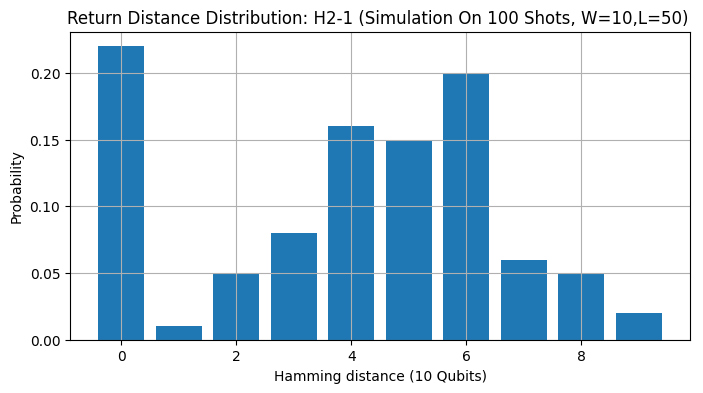

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.bar(xs, pdf)
plt.xlabel("Hamming distance (10 Qubits)")
plt.ylabel("Probability")
plt.title("Return Distance Distribution: H2-1 (Simulation On 100 Shots, W=10,L=50) ")
plt.grid()
plt.show()

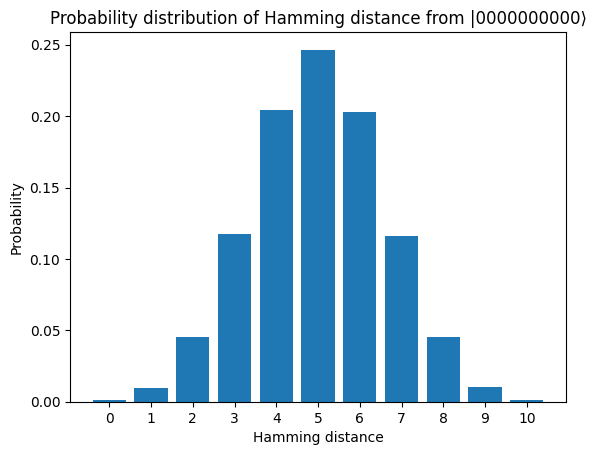

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def hamming_probability(n_samples=10000, n_bits=10, seed=None):
    rng = np.random.default_rng(seed)

    # generate random bitstrings
    bitstrings = rng.integers(0, 2, size=(n_samples, n_bits))

    # Hamming distance from all-zero state
    distances = bitstrings.sum(axis=1)

    # compute probabilities
    counts = np.bincount(distances, minlength=n_bits+1)
    probabilities = counts / n_samples

    return probabilities


# parameters
n_bits = 10
n_samples = 50000

prob = hamming_probability(n_samples=n_samples, n_bits=n_bits, seed=1)

# plot
d = np.arange(n_bits + 1)

plt.figure()
plt.bar(d, prob)
plt.xlabel("Hamming distance")
plt.ylabel("Probability")
plt.title("Probability distribution of Hamming distance from |0000000000⟩")
plt.xticks(d)
plt.show()

In [ ]:

def generate_time_reversal_breaking_random_brick_wall(
    L: int,
    W: int,
    unperturbed: bool = False,
    pert_site: int | None = None,
    pert_op: str = "measure",
    probe_site: int | None = None,
    probe_angle: float = 0.5,
    add_barrier: bool = True,
    do_reset: bool = False,
    seed: int | None = None,
    init_seed: int | None = None,
    meas_seed: int | None = None,
    meas_seed_ud: int | None = None,
    n_meas_total: int = 0,
) -> Circuit:
    """
    Parameters:
    L (int): The length of circuit or number of layers.
    W (int): The width of the circuit or number of qubits.
    unperturbed (bool): When True the mid-circuit perturbation is suppressed;
    stochastic measurements are unaffected.
    pert_site (int): Qubit index where the mid-circuit perturbation is inserted.
    Defaults to W // 2.
    pert_op (str): Operation applied at pert_site when unperturbed=False.
    Use "measure" for a projective measurement or any single-qubit gate name
    supported by pytket Circuit (e.g. "X", "Y", "Z", "H", "S", "T").
    probe_site (int): Qubit prepared in an equal superposition before U and
    measured after U†. Must differ from pert_site. Defaults to 0.
    probe_angle (float): Ry rotation angle (in pytket half-turns, i.e. units of π)
    applied to probe_site during state preparation. 0.5 → Ry(π/2), -0.5 → Ry(-π/2).
    do_reset (bool): After a "measure" perturbation, reset the qubit to |0>.
    meas_seed (int): Seed for U measurement site selection.
    meas_seed_ud (int): Seed for U† measurement site selection. Independent of
    meas_seed so the forward and backward channels have uncorrelated measurement
    patterns. Defaults to meas_seed + 1 when meas_seed is given, else seed + 1.
    n_meas_total (int): Exact number of stochastic measurements per channel
    (U and U† each get n_meas_total independently placed measurements).
    Distributed uniformly across L-1 eligible layers; sites chosen without
    replacement per layer via the respective meas_rng.

    Returns:
    Circuit: State-prep → U → Perturbation → U† → probe measurement circuit.

    """

    if pert_op != "measure" and pert_op not in _PERT_UNITARY_OPS:
        raise ValueError(
            f"Unsupported pert_op {pert_op!r}. Use 'measure' or one of {_PERT_UNITARY_OPS}."
        )

    if W % 2 != 0:
        raise ValueError("Circuit only defined for even # of qubits.")

    rng = np.random.default_rng(seed=seed)
    init_rng = np.random.default_rng(seed=init_seed if init_seed is not None else seed)
    _ms_u = meas_seed if meas_seed is not None else seed
    _ms_ud = meas_seed_ud if meas_seed_ud is not None else (_ms_u + 1 if _ms_u is not None else 1)
    meas_rng_u = np.random.default_rng(seed=_ms_u)
    meas_rng_ud = np.random.default_rng(seed=_ms_ud)

    if pert_site is None:
        pert_site = W // 2
    if probe_site is None:
        probe_site = 0
    if probe_site == pert_site:
        raise ValueError(
            f"probe_site and pert_site must differ (both are {probe_site})."
        )

    def layer_pairs(l):
        if l % 2 == 0:
            return [(2 * w, 2 * w + 1) for w in range(W // 2)]
        else:
            return [(2 * w + 1, 2 * w + 2) for w in range(W // 2 - 1)]

    # Stochastic measurements are placed only on qubits that participate in a
    # two-qubit gate that layer (paired sites). Unpaired boundary qubits (0 and
    # W-1 in odd layers) are idle and never receive stochastic measurements.
    #
    # U and U† each receive n_meas_total measurements distributed independently:
    # each channel gets its own floor/ceil split across L-1 eligible layers and
    # its own random site selection within each layer. The two RNGs are seeded
    # from meas_seed and meas_seed_ud respectively, ensuring zero correlation.
    #
    # Tuple layout in forward:
    #   pairs_data[k] = (a,b,g,i,j, ai,bi,ci,aj,bj,cj, mi_u,mj_u, mi_ud,mj_ud)
    num_eligible = max(L - 1, 0)

    def _layer_counts(rng_):
        counts = [0] * L
        if num_eligible > 0 and n_meas_total > 0:
            clamped = min(n_meas_total, W * num_eligible)
            base, rem = divmod(clamped, num_eligible)
            for rank, l in enumerate(rng_.permutation(num_eligible)):
                counts[l] = base + (1 if rank < rem else 0)
        return counts

    layer_meas_u  = _layer_counts(meas_rng_u)
    layer_meas_ud = _layer_counts(meas_rng_ud)

    forward = []
    for l in range(L):
        pairs_in_layer = layer_pairs(l)
        paired = sorted({q for pair in pairs_in_layer for q in pair})

        def _pick(rng_, count):
            n = min(count, len(paired))
            return set(rng_.choice(len(paired), size=n, replace=False).tolist()) if n > 0 else set()

        chosen_u  = {paired[k] for k in _pick(meas_rng_u,  layer_meas_u[l])}
        chosen_ud = {paired[k] for k in _pick(meas_rng_ud, layer_meas_ud[l])}

        pairs_data = []
        for i, j in pairs_in_layer:
            a, b, g = rng.normal(size=3)
            ai, bi, ci = rng.uniform(0, 2, size=3)  # TK1 angles for qubit i
            aj, bj, cj = rng.uniform(0, 2, size=3)  # TK1 angles for qubit j
            pairs_data.append((
                a, b, g, i, j, ai, bi, ci, aj, bj, cj,
                i in chosen_u, j in chosen_u,
                i in chosen_ud, j in chosen_ud,
            ))

        forward.append(pairs_data)

    # bit 0 : scratch — receives every mid-circuit measurement (outcomes discarded)
    # bit 1 : probe — final readout only
    n_bits = 2
    probe_bit = 1
    qc = Circuit(W, n_bits)

    barrier_sequence = list(range(W))
    all_bits = list(range(n_bits))

    # --- State preparation ---
    # probe_site → equal superposition via Ry; all other sites → random {I, X, Y, Z}.
    qc.Ry(probe_angle, probe_site)
    for q in range(W):
        if q == probe_site:
            continue
        op = init_rng.choice(["I"] + _INIT_PAULIS)
        if op != "I":
            getattr(qc, op)(q)

    # Build U: gates then U-channel measurements for paired qubits only.
    # Unpaired boundary qubits are idle in odd layers and never measured.
    # All mid-circuit outcomes go to scratch bit 0 (overwritten, never read back).
    for pairs_data in forward:
        for a, b, g, i, j, ai, bi, ci, aj, bj, cj, mi_u, mj_u, _, _ in pairs_data:
            qc.TK2(a, b, g, i, j)
            qc.TK1(ai, bi, ci, i)
            qc.TK1(aj, bj, cj, j)
            if mi_u:
                qc.Measure(i, 0)
            if mj_u:
                qc.Measure(j, 0)
        if add_barrier:
            qc.add_barrier(qubits=barrier_sequence, bits=all_bits)

    # Mid-circuit perturbation (toggled off when unperturbed=True).
    if not unperturbed:
        if pert_op == "measure":
            qc.Measure(pert_site, 0)
            if do_reset:
                qc.Reset(pert_site)
        else:
            getattr(qc, pert_op)(pert_site)

    if add_barrier:
        qc.add_barrier(qubits=barrier_sequence, bits=all_bits)

    # Apply U†: inverse of the unitary block is TK1_j† → TK1_i† → TK2†, then measurements.
    for pairs_data in reversed(forward):
        for a, b, g, i, j, ai, bi, ci, aj, bj, cj, meas_i, meas_j in reversed(pairs_data):
            qc.TK1(-cj, -bj, -aj, j)
            qc.TK1(-ci, -bi, -ai, i)
            qc.TK2(-a, -b, -g, i, j)
            if meas_j:
                qc.Measure(j, 0)
            if meas_i:
                qc.Measure(i, 0)
        if add_barrier:
            qc.add_barrier(qubits=barrier_sequence, bits=all_bits)

    # Final probe measurement.
    qc.Measure(probe_site, probe_bit)

    return qc

In [11]:


_PERT_UNITARY_OPS = {"X", "Y", "Z", "H", "S", "T"}
_INIT_PAULIS = ["X", "Y", "Z"]  # identity handled by skipping

In [12]:
qc= generate_time_reversal_breaking_random_brick_wall(4,4,n_meas_total=int(.4*5*5))
render_circuit_jupyter(qc)

ValueError: not enough values to unpack (expected 2, got 1)